# E-Commerce Sales Forecasting and Intelligent Reporting

This notebook prepares the Olist e-commerce sales fact table for time-series analysis, explores sales patterns, trains forecasting models, evaluates model performance, and prepares results for reporting.

The modeling dataset is created by aggregating order-item revenue into daily sales. The final daily time series contains 730 daily records. The last 60 days are used as the test set, while the earlier 670 days are used for training. This keeps the time order intact, which is required for forecasting.


In [2]:
import pandas as pd

sales_fact = pd.read_csv("Dataset\\sales_fact.csv")

sales_fact.columns = sales_fact.columns.str.strip()

sales_fact["order_id"] = sales_fact["order_id"].astype("string")
sales_fact["customer_city"] = sales_fact["customer_city"].astype("string")
sales_fact["customer_state"] = sales_fact["customer_state"].astype("string")
sales_fact["product_category"] = sales_fact["product_category"].astype("string")
sales_fact["payment_types_used"] = sales_fact["payment_types_used"].astype("string")

sales_fact["order_item_id"] = pd.to_numeric(sales_fact["order_item_id"], errors="coerce").astype("Int64")
sales_fact["quantity"] = pd.to_numeric(sales_fact["quantity"], errors="coerce").astype("Int64")
sales_fact["payment_type_count"] = pd.to_numeric(sales_fact["payment_type_count"], errors="coerce").astype("Int64")

sales_fact["price"] = pd.to_numeric(sales_fact["price"], errors="coerce")
sales_fact["total_revenue"] = pd.to_numeric(sales_fact["total_revenue"], errors="coerce")
sales_fact["total_payment_value"] = pd.to_numeric(sales_fact["total_payment_value"], errors="coerce")
sales_fact["delivery_time_days"] = pd.to_numeric(sales_fact["delivery_time_days"], errors="coerce")

sales_fact["order_date"] = pd.to_datetime(
    sales_fact["order_date"],
    errors="coerce"
)

sales_fact["order_date"] = sales_fact["order_date"].dt.strftime("%Y-%b-%d %H:%M:%S")

sales_fact.info()
sales_fact.head()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  string 
 1   order_item_id        112650 non-null  Int64  
 2   order_date           112650 non-null  str    
 3   customer_city        112650 non-null  string 
 4   customer_state       112650 non-null  string 
 5   product_category     112650 non-null  string 
 6   price                112650 non-null  float64
 7   quantity             112650 non-null  Int64  
 8   total_revenue        112650 non-null  float64
 9   payment_types_used   112650 non-null  string 
 10  payment_type_count   112650 non-null  Int64  
 11  total_payment_value  112650 non-null  float64
 12  delivery_time_days   110196 non-null  float64
dtypes: Int64(3), float64(4), str(1), string(5)
memory usage: 20.9 MB


,order_id,order_item_id,order_date,customer_city,customer_state,product_category,price,quantity,total_revenue,payment_types_used,payment_type_count,total_payment_value,delivery_time_days
0,001d8f0e34a38c37f7dba2a37d4eba8b,2,2017-May-14 17:19:44,sao paulo,SP,health_beauty,18.99,1,18.99,credit_card,1,53.54,11.83
1,00010242fe8c5a6d1ba2dd792cb16214,1,2017-Sep-13 08:59:02,campos dos goytacazes,RJ,cool_stuff,58.90,1,58.90,credit_card,1,72.19,7.61
2,00018f77f2f0320c557190d7a144bdd3,1,2017-Apr-26 10:53:06,santa fe do sul,SP,pet_shop,239.90,1,239.90,credit_card,1,259.83,16.22
3,000229ec398224ef6ca0657da4fc703e,1,2018-Jan-14 14:33:31,para de minas,MG,furniture_decor,199.00,1,199.00,credit_card,1,216.87,7.95
4,00024acbcdf0a6daa1e931b038114c75,1,2018-Aug-08 10:00:35,atibaia,SP,perfumery,12.99,1,12.99,credit_card,1,25.78,6.15


1.Aggregation by day to for modeling purposes

## Data quality check

This step checks whether any columns still contain missing values after the SQL data preparation. Delivery-time nulls are acceptable for this forecasting task because delivery time is not used to predict sales revenue.


In [3]:
sales_fact.isnull().sum()

order_id                  0
order_item_id             0
order_date                0
customer_city             0
customer_state            0
product_category          0
price                     0
quantity                  0
total_revenue             0
payment_types_used        0
payment_type_count        0
total_payment_value       0
delivery_time_days     2454
dtype: int64

## Date preparation

 A helper datetime column is created so the data can be grouped by day, week, month, quarter, and season.


In [4]:
# Create datetime helper column for aggregation only
sales_fact["order_date_dt"] = pd.to_datetime(
    sales_fact["order_date"],
    format="%Y-%b-%d %H:%M:%S",
    errors="raise"
)

## Daily sales aggregation

Daily aggregation is used as the main modeling level. Each row in the modeling time series represents one calendar day and the total sales revenue recorded on that day.


In [5]:
# Aggregate by day
daily_sales = (
    sales_fact
    .groupby(sales_fact["order_date_dt"].dt.date)["total_revenue"]
    .sum()
    .reset_index()
)

daily_sales.columns = ["date", "daily_sales"]
daily_sales["date"] = pd.to_datetime(daily_sales["date"])

daily_sales.head()

,date,daily_sales
0,2016-09-04,72.89
1,2016-09-05,59.50
2,2016-09-15,134.97
3,2016-10-02,100.00
4,2016-10-03,463.48


## Weekly sales aggregation

Weekly aggregation is created as an additional comparison view. It reduces daily noise and gives a broader view of revenue movement over time.


In [6]:
# Aggregate by week
weekly_sales = (
    sales_fact
    .groupby(pd.Grouper(key="order_date_dt", freq="W"))["total_revenue"]
    .sum()
    .reset_index()
)

weekly_sales.columns = ["week", "weekly_sales"]

weekly_sales.head()

,week,weekly_sales
0,2016-09-04,72.89
1,2016-09-11,59.50
2,2016-09-18,134.97
3,2016-09-25,0.00
4,2016-10-02,100.00


## Monthly sales aggregation

Monthly sales are created for business-level trend review. Monthly data is useful for reporting, but it has fewer observations than daily data, so daily data remains the main modeling series.


In [7]:
# Aggregate by month
monthly_sales = (
    sales_fact
    .groupby(pd.Grouper(key="order_date_dt", freq="MS"))["total_revenue"]
    .sum()
    .reset_index()
)

monthly_sales.columns = ["month", "monthly_sales"]

monthly_sales.head()

,month,monthly_sales
0,2016-09-01,267.36
1,2016-10-01,49507.66
2,2016-11-01,0.00
3,2016-12-01,10.90
4,2017-01-01,120312.87


## Quarterly sales aggregation

Quarterly aggregation summarizes revenue across calendar quarters. This is useful for Power BI reporting and high-level sales trend analysis.


In [8]:
# Aggregate by quarter
quarterly_sales = (
    sales_fact
    .groupby(pd.Grouper(key="order_date_dt", freq="QS"))["total_revenue"]
    .sum()
    .reset_index()
)

quarterly_sales.columns = ["quarter", "quarterly_sales"]
quarterly_sales["quarter_label"] = quarterly_sales["quarter"].dt.to_period("Q").astype(str)

quarterly_sales.head()

,quarter,quarterly_sales,quarter_label
0,2016-07-01,267.36,2016Q3
1,2016-10-01,49518.56,2016Q4
2,2017-01-01,741960.19,2017Q1
3,2017-04-01,1299036.97,2017Q2
4,2017-07-01,1696404.85,2017Q3


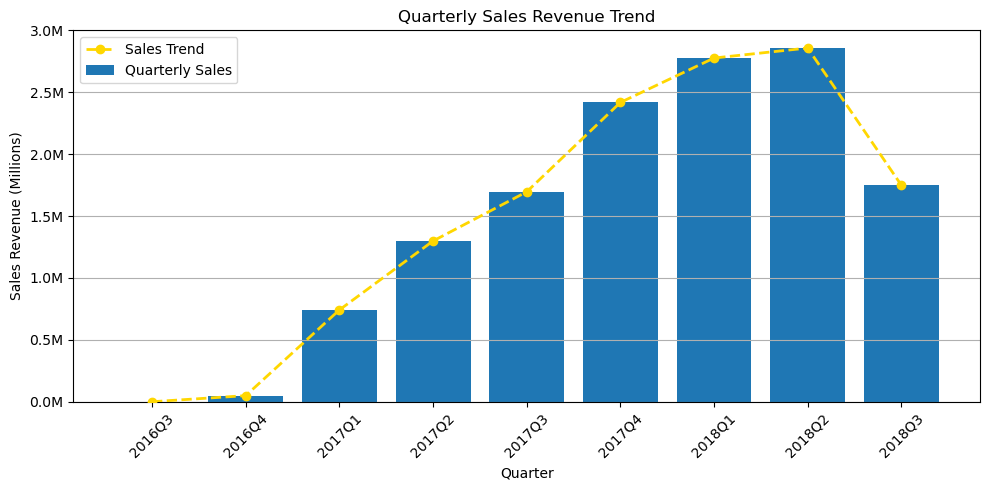

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 5))

plt.bar(
    quarterly_sales["quarter_label"],
    quarterly_sales["quarterly_sales"],
    label="Quarterly Sales"
)

plt.plot(
    quarterly_sales["quarter_label"],
    quarterly_sales["quarterly_sales"],
    marker="o",
    linewidth=2,
    linestyle="--",
    color="gold",
    label="Sales Trend",
    zorder=3
)

plt.title("Quarterly Sales Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales Revenue (Millions)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)

plt.xticks(rotation=45)
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()

## Seasonal sales aggregation

Seasons are assigned using Brazil's Southern Hemisphere seasons. This allows sales to be compared across Summer, Autumn, Winter, and Spring.


In [10]:
# Aggregate by season - Brazil is Southern Hemisphere
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

sales_fact["season"] = sales_fact["order_date_dt"].dt.month.apply(get_season)

seasonal_sales = (
    sales_fact
    .groupby("season")["total_revenue"]
    .sum()
    .reset_index()
)

seasonal_sales["season"] = pd.Categorical(
    seasonal_sales["season"],
    categories=["Summer", "Autumn", "Winter", "Spring"],
    ordered=True
)

seasonal_sales = seasonal_sales.sort_values("season")

seasonal_sales

,season,total_revenue
2,Summer,2905750.03
0,Autumn,4216721.54
3,Winter,4120359.62
1,Spring,2348812.51


In [11]:
# Aggregate by season

def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

sales_fact["season"] = sales_fact["order_date_dt"].dt.month.apply(get_season)

seasonal_sales = (
    sales_fact
    .groupby("season")["total_revenue"]
    .sum()
    .reset_index()
)

seasonal_sales["season"] = pd.Categorical(
    seasonal_sales["season"],
    categories=["Summer", "Autumn", "Winter", "Spring"],
    ordered=True
)

seasonal_sales = seasonal_sales.sort_values("season")

seasonal_sales

,season,total_revenue
2,Summer,2905750.03
0,Autumn,4216721.54
3,Winter,4120359.62
1,Spring,2348812.51


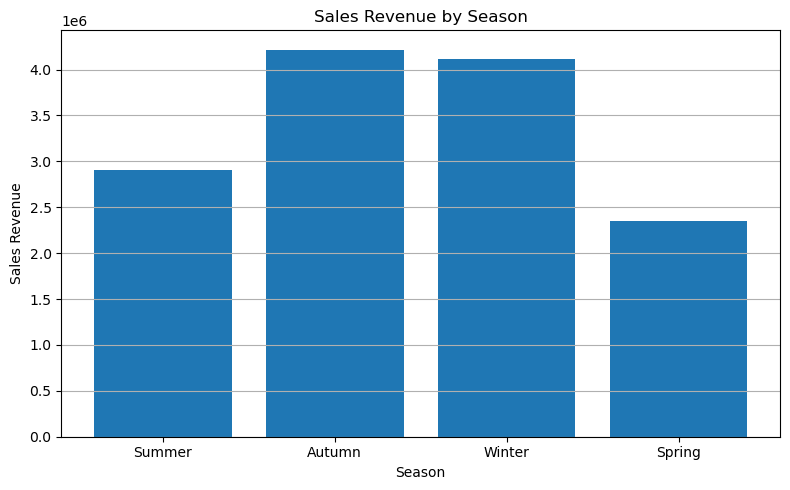

In [12]:
# Visualize seasonal sales
plt.figure(figsize=(8, 5))
plt.bar(seasonal_sales["season"], seasonal_sales["total_revenue"])
plt.title("Sales Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Sales Revenue")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Part III: Models 

1.  ARIMA 
2. SARIMA
3. 

## Complete daily time series

ARIMA and LSTM require a consistent time interval. A complete daily date range is created, and missing sales days are filled with zero sales. This keeps the time series evenly spaced.


In [13]:
# Create a complete daily date range
full_date_range = pd.date_range(
    start=daily_sales["date"].min(),
    end=daily_sales["date"].max(),
    freq="D"
)

# Reindex daily sales so missing days become 0 sales
daily_sales_full = (
    daily_sales
    .set_index("date")
    .reindex(full_date_range)
    .fillna(0)
    .rename_axis("date")
    .reset_index()
)

daily_sales_full.head(10)

,date,daily_sales
0,2016-09-04,72.89
1,2016-09-05,59.50
2,2016-09-06,0.00
3,2016-09-07,0.00
4,2016-09-08,0.00
5,2016-09-09,0.00
6,2016-09-10,0.00
7,2016-09-11,0.00
8,2016-09-12,0.00
9,2016-09-13,0.00


## Zero-sales day summary

This summarizes how many days had no recorded sales after the complete daily timeline was created.


In [14]:
# Check how many days have zero sales vs actual sales
zero_sales_summary = pd.DataFrame({
    "total_days": [len(daily_sales_full)],
    "zero_sales_days": [(daily_sales_full["daily_sales"] == 0).sum()],
    "non_zero_sales_days": [(daily_sales_full["daily_sales"] > 0).sum()],
    "zero_sales_percent": [round((daily_sales_full["daily_sales"] == 0).mean() * 100, 2)]
})

zero_sales_summary

,total_days,zero_sales_days,non_zero_sales_days,zero_sales_percent
0,730,114,616,15.62


Anomality detection  zscore (value - mean)/standard_deviation(z score is calculated for each)
if a data is more than 3 standard deviation (outside of the 99.7) of our data it can be cosidered anomaly

## Anomaly detection

A z-score is used to flag unusually high or low daily sales values. Values with an absolute z-score greater than 3 are considered unusual and are reviewed as possible anomalies.


In [15]:
# Calculate Z-score for daily sales
daily_sales_full["z_score"] = (
    daily_sales_full["daily_sales"] - daily_sales_full["daily_sales"].mean()
) / daily_sales_full["daily_sales"].std()

# Flag anomalies
daily_sales_full["is_anomaly"] = daily_sales_full["z_score"].abs() > 3

# View anomalies
daily_anomalies = daily_sales_full[daily_sales_full["is_anomaly"] == True]

daily_anomalies.sort_values("daily_sales", ascending=False)

,date,daily_sales,z_score,is_anomaly
446,2017-11-24,152653.74,9.524297,True
447,2017-11-25,60923.48,3.006105,True


The  are aligned with black friday

## Final modeling series

The final modeling series keeps the daily sales values indexed by date. This is the time series used for train/test splitting and model training.


In [16]:
# Prepare final daily time series for modeling
arima_data = daily_sales_full[["date", "daily_sales", "z_score", "is_anomaly"]].copy()

# Set date as index because ARIMA works with time-indexed data
arima_data = arima_data.set_index("date")

# Keep only the sales column for the model
sales_series = arima_data["daily_sales"]

sales_series.head()

date
2016-09-04    72.89
2016-09-05    59.50
2016-09-06     0.00
2016-09-07     0.00
2016-09-08     0.00
Name: daily_sales, dtype: float64

## Frequency check

The series is converted to official daily frequency using `asfreq("D")`. This confirms that the model receives one observation per day with no missing dates.


In [17]:
# Confirm daily frequency and no missing dates
print(sales_series.index.min())
print(sales_series.index.max())
print(sales_series.index.freq)

sales_series = sales_series.asfreq("D")

print(sales_series.index.freq)
print(sales_series.isna().sum())

2016-09-04 00:00:00
2018-09-03 00:00:00
None
<Day>
0


In [18]:
#Test Training split

## Train/test split

For time-series forecasting, the split must respect time order. The first 670 days are used for training, and the last 60 days are reserved as the future test period.


In [19]:
train = sales_series.iloc[:-60]   # everything except last 60 days
test = sales_series.iloc[-60:]    # last 60 days only

In [20]:
print("Train size:", len(train))
print("Test size:", len(test))
print("Train date range:", train.index.min(), "to", train.index.max())
print("Test date range:", test.index.min(), "to", test.index.max())

Train size: 670
Test size: 60
Train date range: 2016-09-04 00:00:00 to 2018-07-05 00:00:00
Test date range: 2018-07-06 00:00:00 to 2018-09-03 00:00:00


In [21]:
import sys
!{sys.executable} -m pip install --upgrade "statsmodels==0.14.6

In [22]:
import statsmodels
import pandas as pd

print("statsmodels:", statsmodels.__version__)
print("pandas:", pd.__version__)

statsmodels: 0.14.6
pandas: 3.0.3


checking if  our model is stable

## Stationarity and differencing

First differencing is used to measure day-to-day sales changes. This helps stabilize the series before ARIMA modeling. Based on the comparison, `d = 1` is selected for ARIMA.


In [23]:
# First difference the training data
train_diff_1 = train.diff().dropna()

# Compare original train vs first-differenced train
stationarity_compare = pd.DataFrame({
    "series": ["Original train", "First difference"],
    "mean": [train.mean(), train_diff_1.mean()],
    "standard_deviation": [train.std(), train_diff_1.std()],
    "min": [train.min(), train_diff_1.min()],
    "max": [train.max(), train_diff_1.max()]
})

stationarity_compare

,series,mean,standard_deviation,min,max
0,Original train,17880.002284,13818.021169,0.00,152653.74
1,First difference,42.954320,8151.144834,-91730.26,107940.86


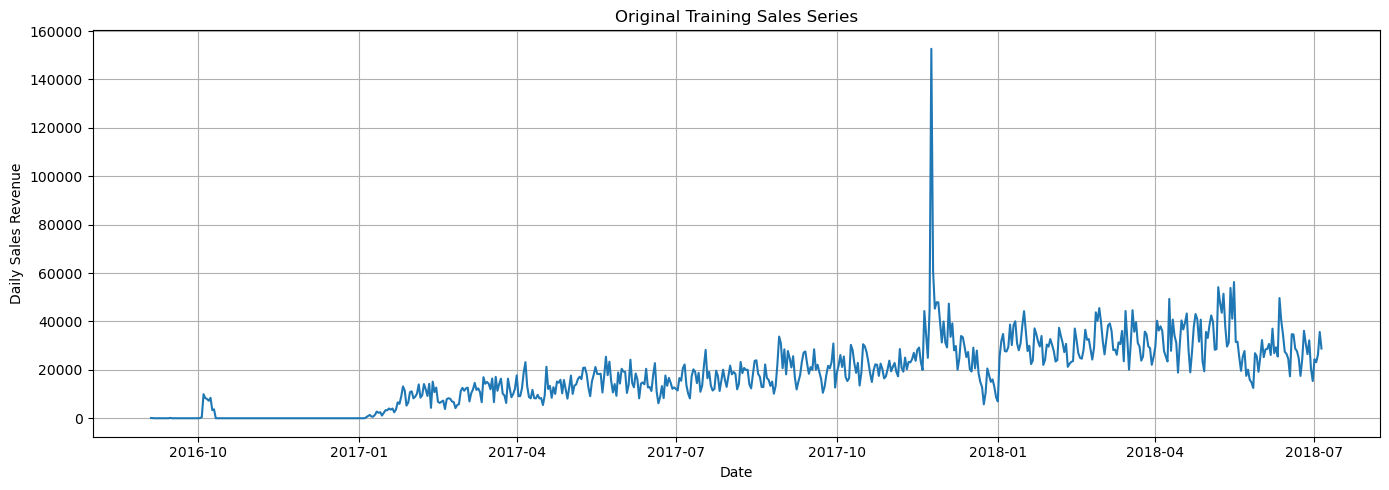

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train)
plt.title("Original Training Sales Series")
plt.xlabel("Date")
plt.ylabel("Daily Sales Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()

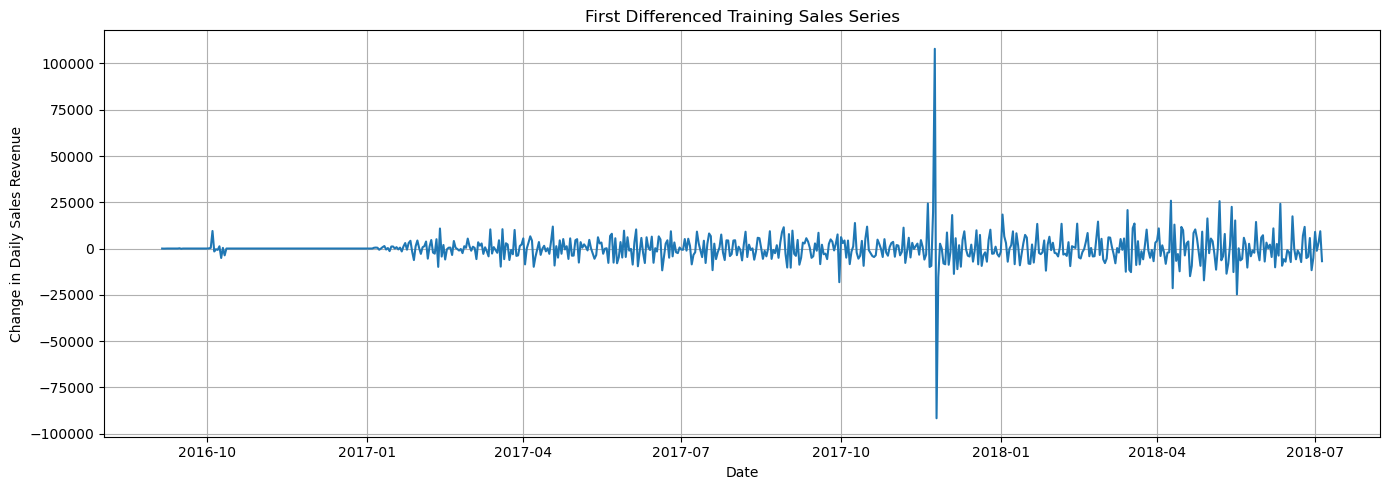

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(train_diff_1.index, train_diff_1)
plt.title("First Differenced Training Sales Series")
plt.xlabel("Date")
plt.ylabel("Change in Daily Sales Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()

### Stationarity and Differencing Decision

The original training sales series had an average daily revenue of R$17,880.00, while the first-differenced series had an average daily change of R$42.95.

This means that after differencing, the series is centered around a small average daily change instead of a large sales level. The standard deviation also decreased from 13,818.02 to 8,151.14, showing that first differencing helped stabilize the series.

Because the first-differenced series is more stable and does not show a strong ongoing upward or downward drift, `d = 1` is selected for ARIMA modeling.

Second differencing is not used because it may remove too much useful information from the sales pattern.

## Daily ARIMA model

The ARIMA model is trained on the training period and forecasts the next 60 daily sales values. The forecast is compared against the actual test-period sales.


In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

arima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = mean_squared_error(test, arima_forecast) ** 0.5



WAPE = sum(|actual - forecast|) / sum(actual) × 100

## WAPE evaluation

WAPE measures total absolute error as a percentage of total actual sales. It is useful for sales forecasting because it is less distorted by very small daily sales values than MAPE.


In [27]:
arima_wape = (
    abs(test - arima_forecast).sum() / test.sum()
) * 100

print("ARIMA WAPE:", arima_wape)

ARIMA WAPE: 43.52214544620638


In [28]:
print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA WAPE:", arima_wape)

ARIMA MAE: 11693.255631359692
ARIMA RMSE: 14271.560527412
ARIMA WAPE: 43.52214544620638


## ARIMA forecast results

This table compares actual daily sales to ARIMA predictions for each test-period date and calculates the forecast error.


In [29]:
forecast_results = pd.DataFrame({
    "date": test.index,
    "actual_sales": test.values,
    "arima_forecast": arima_forecast.values
})

forecast_results["error"] = forecast_results["actual_sales"] - forecast_results["arima_forecast"]
forecast_results["absolute_error"] = abs(forecast_results["error"])

forecast_results["percentage_error"] = (
    forecast_results["absolute_error"] / forecast_results["actual_sales"]
) * 100

forecast_results

,date,actual_sales,arima_forecast,error,absolute_error,percentage_error
0,2018-07-06,19005.54,27820.096985,-8814.556985,8814.556985,4.637888e+01
1,2018-07-07,9076.56,27486.188977,-18409.628977,18409.628977,2.028261e+02
2,2018-07-08,14410.79,27373.480893,-12962.690893,12962.690893,8.995129e+01
3,2018-07-09,19564.85,27335.437144,-7770.587144,7770.587144,3.971708e+01
4,2018-07-10,18724.57,27322.595769,-8598.025769,8598.025769,4.591842e+01
5,2018-07-11,18519.98,27318.261262,-8798.281262,8798.281262,4.750697e+01
6,2018-07-12,28891.77,27316.798182,1574.971818,1574.971818,5.451282e+00
7,2018-07-13,27644.23,27316.304330,327.925670,327.925670,1.186235e+00
8,2018-07-14,22257.69,27316.137635,-5058.447635,5058.447635,2.272674e+01
9,2018-07-15,30037.49,27316.081368,2721.408632,2721.408632,9.060040e+00


In [30]:
forecast_results.sort_values("absolute_error", ascending=False)

,date,actual_sales,arima_forecast,error,absolute_error,percentage_error
31,2018-08-06,56427.39,27316.052698,29111.337302,29111.337302,5.159079e+01
58,2018-09-02,0.00,27316.052698,-27316.052698,27316.052698,inf
57,2018-09-01,0.00,27316.052698,-27316.052698,27316.052698,inf
56,2018-08-31,0.00,27316.052698,-27316.052698,27316.052698,inf
55,2018-08-30,0.00,27316.052698,-27316.052698,27316.052698,inf
59,2018-09-03,145.00,27316.052698,-27171.052698,27171.052698,1.873866e+04
54,2018-08-29,1546.04,27316.052698,-25770.012698,25770.012698,1.666840e+03
53,2018-08-28,3673.91,27316.052698,-23642.142698,23642.142698,6.435145e+02
52,2018-08-27,5345.91,27316.052698,-21970.142698,21970.142698,4.109711e+02
32,2018-08-07,49178.98,27316.052698,21862.927302,21862.927302,4.445584e+01


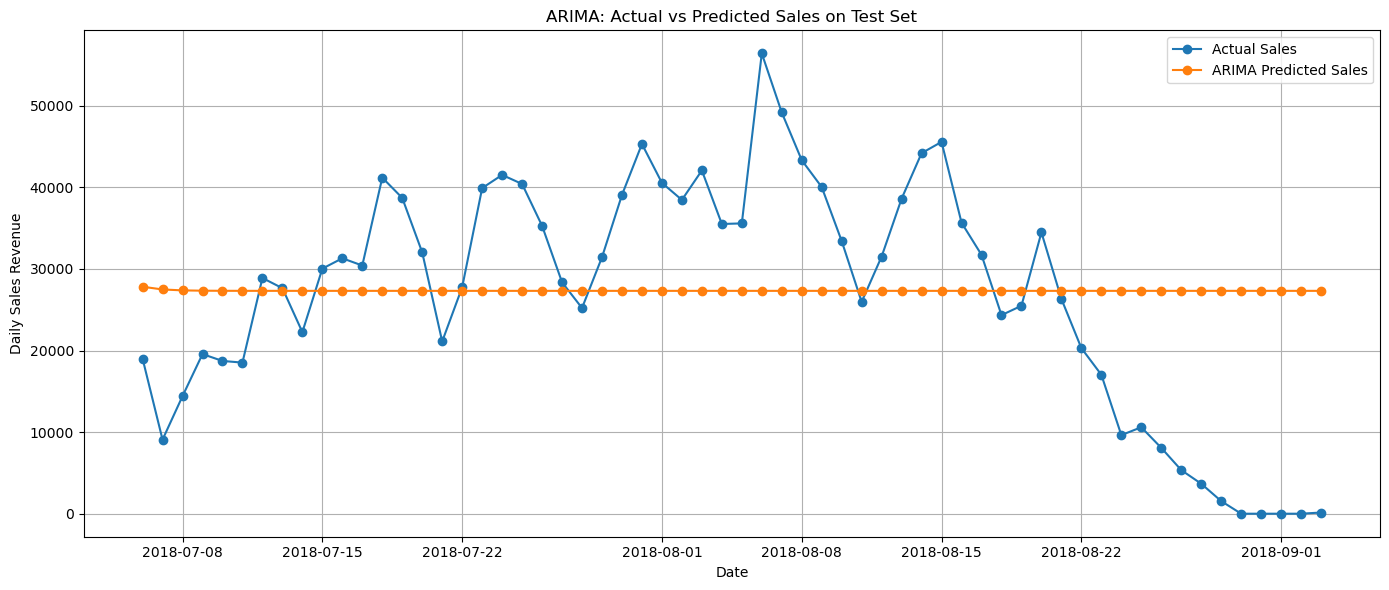

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(test.index, test, label="Actual Sales", marker="o")
plt.plot(test.index, arima_forecast, label="ARIMA Predicted Sales", marker="o")

plt.title("ARIMA: Actual vs Predicted Sales on Test Set")
plt.xlabel("Date")
plt.ylabel("Daily Sales Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#use weekly


## Weekly ARIMA benchmark

A weekly ARIMA model is tested as a benchmark to compare whether reducing daily noise improves forecasting performance.


In [32]:
weekly_sales = sales_series.resample("W").sum()

weekly_train = weekly_sales.iloc[:-8]
weekly_test = weekly_sales.iloc[-8:]

print("Weekly train size:", len(weekly_train))
print("Weekly test size:", len(weekly_test))
print("Weekly test average:", weekly_test.mean())

Weekly train size: 98
Weekly test size: 8
Weekly test average: 175488.5875


In [33]:
weekly_arima_model = SARIMAX(
    weekly_train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

weekly_arima_result = weekly_arima_model.fit()

weekly_arima_forecast = weekly_arima_result.forecast(steps=len(weekly_test))

In [34]:
weekly_arima_mae = mean_absolute_error(weekly_test, weekly_arima_forecast)
weekly_arima_rmse = mean_squared_error(weekly_test, weekly_arima_forecast) ** 0.5
weekly_arima_wape = (abs(weekly_test - weekly_arima_forecast).sum() / weekly_test.sum()) * 100

print("Weekly ARIMA MAE:", weekly_arima_mae)
print("Weekly ARIMA RMSE:", weekly_arima_rmse)
print("Weekly ARIMA WAPE:", weekly_arima_wape)

Weekly ARIMA MAE: 96504.08239307773
Weekly ARIMA RMSE: 109410.97505493429
Weekly ARIMA WAPE: 54.99165716008611


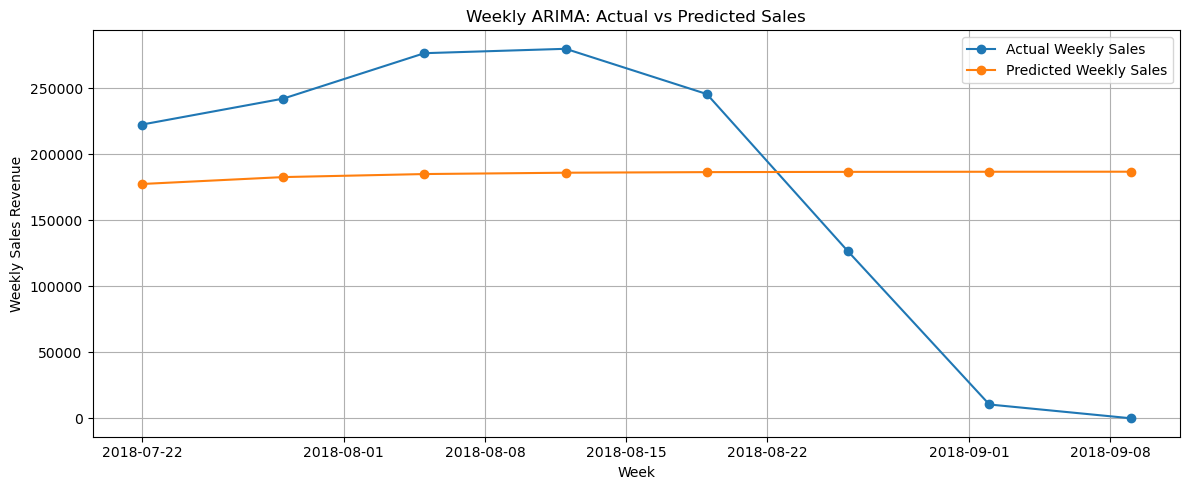

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(weekly_test.index, weekly_test, label="Actual Weekly Sales", marker="o")
plt.plot(weekly_test.index, weekly_arima_forecast, label="Predicted Weekly Sales", marker="o")

plt.title("Weekly ARIMA: Actual vs Predicted Sales")
plt.xlabel("Week")
plt.ylabel("Weekly Sales Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

LSTM

In [36]:
!pip install tensorflow

In [37]:
import sys
!{sys.executable} -m pip install tensorflow

## LSTM model setup

LSTM is a neural-network sequence model. It uses a lookback window of previous daily sales values to predict the next day. The data is scaled before modeling because neural networks train better on normalized values.


In [38]:
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

Scale train/test

In [39]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

Create LSTM sequences

## LSTM sequence creation

A 30-day lookback window is used. Each training example contains 30 previous days of sales and the target is the next day's sales.


In [40]:
lookback = 30

X_train_lstm = []
y_train_lstm = []

for i in range(lookback, len(train_scaled)):
    X_train_lstm.append(train_scaled[i-lookback:i, 0])
    y_train_lstm.append(train_scaled[i, 0])

X_train_lstm = np.array(X_train_lstm)
y_train_lstm = np.array(y_train_lstm)

X_train_lstm = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    X_train_lstm.shape[1],
    1
)

print(X_train_lstm.shape)
print(y_train_lstm.shape)

(640, 30, 1)
(640,)


Build and train LSTM

## LSTM training

The LSTM model is trained using 50 memory units. Early stopping helps stop training when the loss no longer improves, reducing unnecessary training rounds.


In [41]:
tf.random.set_seed(42)

lstm_model = Sequential()

lstm_model.add(
    LSTM(50, activation="tanh", input_shape=(lookback, 1))
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

early_stop = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


c:\Users\Meklit\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0034
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024
Epoch 13/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024
Epoch 14/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023
Epoch 15/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023
Epoch 16/100
40/

Forecast next 60 days

## LSTM recursive forecast

The LSTM predicts the 60-day test period one day at a time. After each predicted day, that prediction becomes part of the next input window.


In [42]:
last_window = train_scaled[-lookback:].reshape(1, lookback, 1)

lstm_predictions_scaled = []

for i in range(len(test)):
    next_pred = lstm_model.predict(last_window, verbose=0)[0, 0]
    lstm_predictions_scaled.append(next_pred)

    last_window = np.append(
        last_window[:, 1:, :],
        [[[next_pred]]],
        axis=1
    )

lstm_forecast = scaler.inverse_transform(
    np.array(lstm_predictions_scaled).reshape(-1, 1)
).flatten()

lstm_forecast = pd.Series(lstm_forecast, index=test.index)

Evaluate

## LSTM evaluation

LSTM predictions are evaluated using MAE, RMSE, and WAPE. These metrics allow the LSTM results to be compared with the ARIMA results.


In [43]:
lstm_mae = mean_absolute_error(test, lstm_forecast)
lstm_rmse = mean_squared_error(test, lstm_forecast) ** 0.5

mape_data_lstm = pd.DataFrame({
    "actual": test,
    "forecast": lstm_forecast
})

mape_data_lstm = mape_data_lstm[mape_data_lstm["actual"] != 0]

lstm_mape = (
    abs((mape_data_lstm["actual"] - mape_data_lstm["forecast"]) / mape_data_lstm["actual"])
    .mean() * 100
)

lstm_wape = (
    abs(test - lstm_forecast).sum() / test.sum()
) * 100

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM WAPE:", lstm_wape)

LSTM MAE: 10688.827852864582
LSTM RMSE: 14008.550305351999
LSTM WAPE: 39.783678312328206


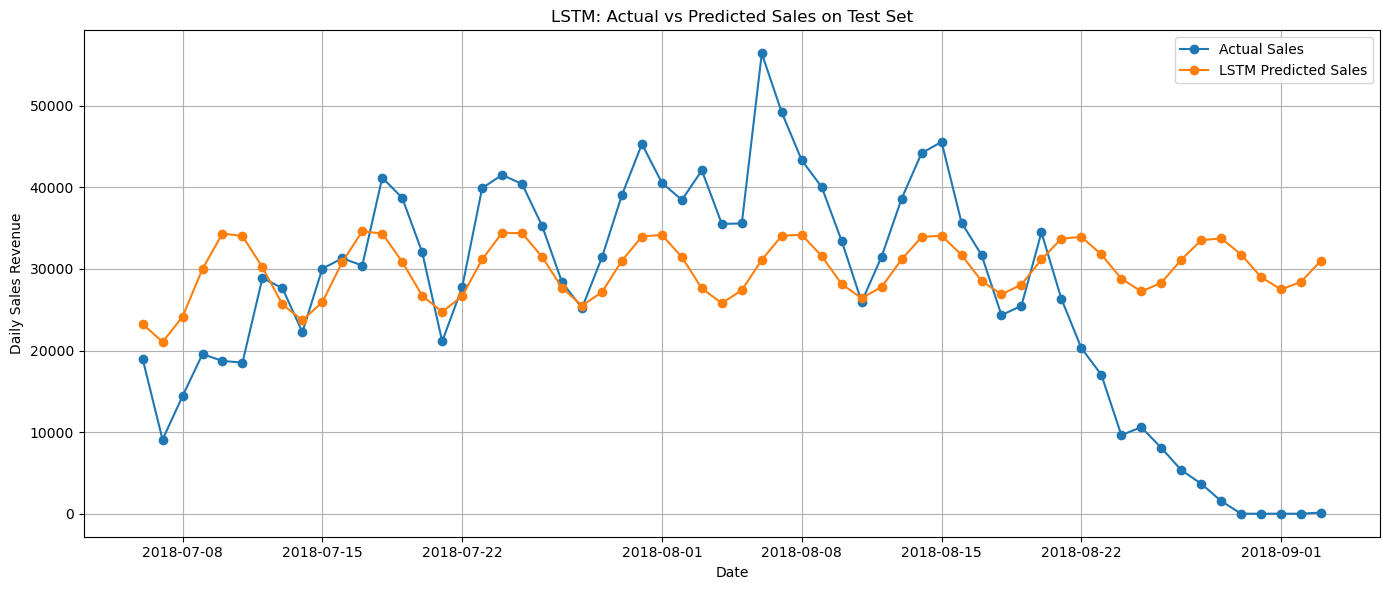

In [44]:
plt.figure(figsize=(14, 6))

plt.plot(test.index, test, label="Actual Sales", marker="o")
plt.plot(test.index, lstm_forecast, label="LSTM Predicted Sales", marker="o")

plt.title("LSTM: Actual vs Predicted Sales on Test Set")
plt.xlabel("Date")
plt.ylabel("Daily Sales Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

LSTM has slightly better RMS But LSTM has worse MAE

## Final model comparison

The table below compares the main forecasting models using MAE, RMSE, and WAPE. Lower values indicate smaller forecast error. WAPE is especially useful for this project because it compares total forecast error against total actual sales over the test period.

Daily ARIMA achieved the lower WAPE, while LSTM achieved a slightly lower RMSE. This means ARIMA performed slightly better in total percentage error, while LSTM reduced larger squared errors slightly. Both models provide a useful baseline for daily sales forecasting and can be further improved with additional features such as holidays, weekday effects, promotions, and product/category-level information.


In [45]:
model_comparison = pd.DataFrame({
    "Model": ["Daily ARIMA", "Weekly ARIMA", "LSTM"],
    "MAE": [arima_mae, weekly_arima_mae, lstm_mae],
    "RMSE": [arima_rmse, weekly_arima_rmse, lstm_rmse],
    "WAPE (%)": [arima_wape, weekly_arima_wape, lstm_wape]
})

model_comparison["MAE"] = model_comparison["MAE"].round(2)
model_comparison["RMSE"] = model_comparison["RMSE"].round(2)
model_comparison["WAPE (%)"] = model_comparison["WAPE (%)"].round(2)

model_comparison


,Model,MAE,RMSE,WAPE (%)
0,Daily ARIMA,11693.26,14271.56,43.52
1,Weekly ARIMA,96504.08,109410.98,54.99
2,LSTM,10688.83,14008.55,39.78
